In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv('SalesData.csv')

In [39]:
df.head()

,ID,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,30-12-2019 00:01,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,29-12-2019 07:03,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,12-12-2019 18:21,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,22-12-2019 15:13,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,18-12-2019 12:38,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


In [54]:
df.shape

(185950, 11)

In [42]:
for col in df.describe(include='object').columns:
    print(df[col].unique())
    print('-'*50)

['Macbook Pro Laptop' 'LG Washing Machine' 'USB-C Charging Cable'
 '27in FHD Monitor' 'AA Batteries (4-pack)' 'Bose SoundSport Headphones'
 'AAA Batteries (4-pack)' 'ThinkPad Laptop' 'Lightning Charging Cable'
 'Google Phone' 'Wired Headphones' 'Apple Airpods Headphones'
 'Vareebadd Phone' 'iPhone' '20in Monitor' '34in Ultrawide Monitor'
 'Flatscreen TV' '27in 4K Gaming Monitor' 'LG Dryer']
--------------------------------------------------
['30-12-2019 00:01' '29-12-2019 07:03' '12-12-2019 18:21' ...
 '09-06-2019 22:07' '26-06-2019 18:35' '25-06-2019 14:33']
--------------------------------------------------
['136 Church St, New York City, NY 10001'
 '562 2nd St, New York City, NY 10001'
 '277 Main St, New York City, NY 10001' ...
 '590 Wilson St, Los Angeles, CA 90001'
 '685 Hickory St, New York City, NY 10001'
 '209 11th St, Atlanta, GA 30301']
--------------------------------------------------
[' New York City' ' San Francisco' ' Atlanta' ' Portland' ' Dallas'
 ' Los Angeles' ' Bos

In [31]:
# for col1 in df.columns:
#     if df[col1].nunique() < 20:
#         print(df[col1].value_counts())
#         print('-'*50)

In [43]:
df.isnull().sum()

ID                  0
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
Sales               0
City                0
Hour                0
dtype: int64

In [44]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')

In [9]:
df.columns

Index(['id', 'order_id', 'product', 'quantity_ordered', 'price_each',
       'order_date', 'purchase_address', 'month', 'sales', 'city', 'hour'],
      dtype='object')

# Data Analysis

Find Total Revenue

In [45]:
# Suppose there is no Sales column the find total revenue like this
# df['revenue'] = df['quantity_ordered'] * df['price_each']
# total_revenue = df['revenue'].sum()

# But we have already sales column
total_revenue = df['sales'].sum()

In [46]:
total_revenue

np.float64(34492035.97)

In [103]:
# Monthly Revenue
month_revenue = df.groupby('month')['sales'].sum()

In [104]:
month_revenue.head()

month
1    1822256.73
2    2202022.42
3    2807100.38
4    3390670.24
5    3152606.75
Name: sales, dtype: float64

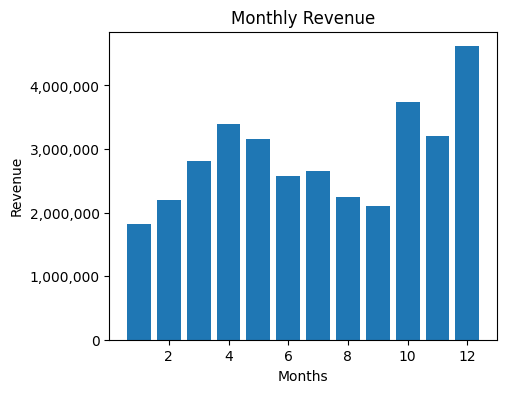

In [143]:
plt.figure(figsize = (5,4))
plt.bar(month_revenue.index, month_revenue.values)
plt.title("Monthly Revenue")
plt.xlabel("Months")
plt.ylabel("Revenue")
# If i use this code i wont get 1e6, i will get revenues in $.
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)
plt.show()

In [95]:
# Product Revenue
product_revenue = df.groupby('product')['sales'].sum()

In [142]:
product_revenue.head()
# product_revenue.sort_values(ascending=False)

product
20in Monitor               454148.71
27in 4K Gaming Monitor    2435097.56
27in FHD Monitor          1132424.50
34in Ultrawide Monitor    2355558.01
AA Batteries (4-pack)      106118.40
Name: sales, dtype: float64

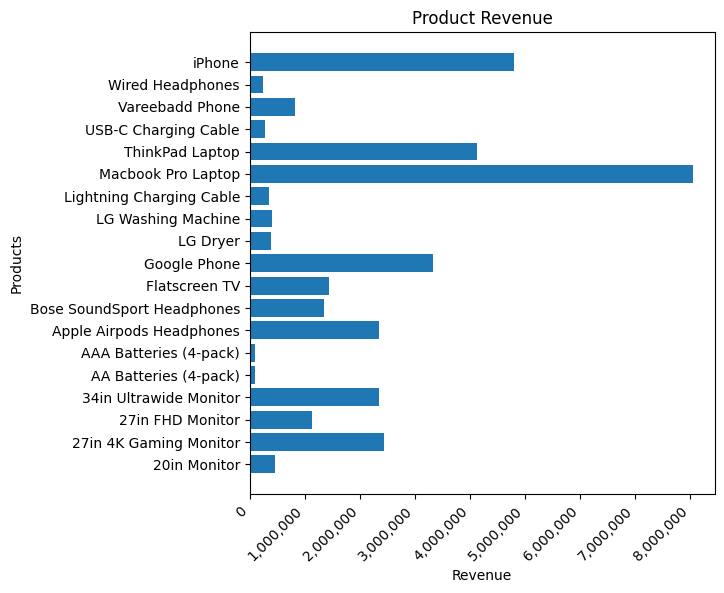

In [140]:
plt.figure(figsize=(6,6))
plt.barh(product_revenue.index,product_revenue)
plt.title("Product Revenue")
plt.ylabel("Products")
plt.xlabel("Revenue")
plt.xticks(rotation=45, ha='right')

plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

In [74]:
# Average Orders
total_orders = df['quantity_ordered'].sum()

In [107]:
average_orders = total_orders/len(df['quantity_ordered'])
# or i can do like this
# average_orders = df['quantity_ordered'].mean()
average_orders

np.float64(1.1243828986286637)

In [100]:
# Hourly Revenue
hrs_revenue = df.groupby('hour')['sales'].sum()

In [106]:
hrs_revenue.head()

hour
0    713721.27
1    460866.88
2    234851.44
3    145757.89
4    162661.01
Name: sales, dtype: float64

In [122]:
# CityWise Revenue
city_revenue = df.groupby('city')['sales'].sum()

In [129]:
city_revenue.head()

city
Atlanta        2795498.58
Austin         1819581.75
Boston         3661642.01
Dallas         2767975.40
Los Angeles    5452570.80
Name: sales, dtype: float64

In [127]:
# City Revenue in Percentage
# city_revenue_percentage = (city_revenue/ city_revenue.sum()) * 100
city_revenue_percentage = (city_revenue/ total_revenue) * 100

In [130]:
city_revenue_percentage.head()

city
Atlanta         8.104765
Austin          5.275368
Boston         10.615906
Dallas          8.024970
Los Angeles    15.808202
Name: sales, dtype: float64

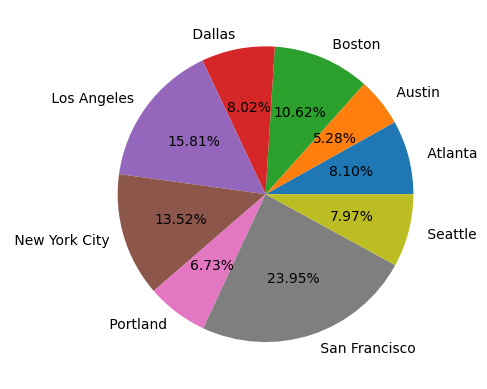

In [139]:
plt.pie(city_revenue, labels=city_revenue.index, autopct='%1.2f%%')
plt.show()